## EDA Unclassified Industry 

#### Load Python Libraries

In [31]:
import pandas as pd
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import string
import numpy as np
from collections import Counter
from wordcloud import WordCloud
tqdm.pandas()

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize NLTK's WordNetLemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/justinvhuang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/justinvhuang/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/justinvhuang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#### Helper Functions

In [25]:
def is_english_word(word):
    return wordnet.synsets(word)

def process_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    text = text.lower()
    
    text = re.sub(r'(\d+\.\d+)', r' \1 ', text)
    
    text = re.sub(r'[^a-z0-9\s.]', '', text)
    
    tokens = word_tokenize(text)
    
    processed_tokens = []
    for token in tokens:
        if (token.replace('.', '', 1).isdigit() or is_english_word(token)) and token not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(token))
    
    return processed_tokens

def plot_count(tokens, n_grams):
  vectorizer = CountVectorizer(ngram_range=n_grams)
  X = vectorizer.fit_transform(tokens)

  ngram_counts = X.sum(axis=0)

  ngram_freq = [(ngram, ngram_counts[0, idx]) for ngram, idx in vectorizer.vocabulary_.items()]
  sorted_ngrams = sorted(ngram_freq, key=lambda x: x[1], reverse=True)
  top_20_words = [word for word, count in sorted_ngrams[:20]]
  top_20_counts = [count for word, count in sorted_ngrams[:20]]

  plt.figure(figsize=(12, 6))
  sns.barplot(x=top_20_counts, y=top_20_words, color='lightblue')
  plt.title('Top 20 Words Bar Plot')
  plt.xlabel('Count')
  plt.ylabel('Word')
  plt.show()

#### Load in Data

In [13]:
df = pd.read_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/unclassified_postings_v2.csv", index_col = 0)
df['text'] = df['body'].progress_apply(lambda text: BeautifulSoup(text, 'html.parser').get_text())
df['tokens'] = df['text'].progress_apply(lambda text: process_text(text))
df['token'] = df['tokens'].apply(lambda x: " ".join(x))

In [28]:
df[['tokens', 'text']]

,tokens,text
0,"[15.00, 20.00, hour, position, range, area, ne...",Between $15.00 and\n$20.00\nPer Hour\nPosition...
1,"[position, range, sioux, fall, sd, metropolita...","Position range in Sioux Falls, SD Metropolitan..."
2,"[transfer, job, order, number, post, date, 111...",Welder/Heat Transfer\n\n\nJob Order Number\n\t...
3,"[niagara, power, transformer, ny, job, detail,...",Welder/Fabricator\nNiagara Power Transformer C...
4,"[welder, santa, fe, spring, ramp, 14903, near,...",MIG WELDER (Santa Fe Springs) MEDLIN RAMPS 149...
...,...,...
219307,"[position, range, sioux, fall, sd, metropolita...","Position range in Sioux Falls, SD Metropolitan..."
219308,"[position, range, sioux, fall, sd, metropolita...","Position range in Sioux Falls, SD Metropolitan..."
219309,"[entry, level, welder, company, people, first,...",Entry Level Welder\n\nCompany: People First St...
219310,"[position, range, sioux, fall, sd, metropolita...","Position range in Sioux Falls, SD Metropolitan..."


#### View Frequency Uni-Gram, Bi-Gram, Tri-Gram

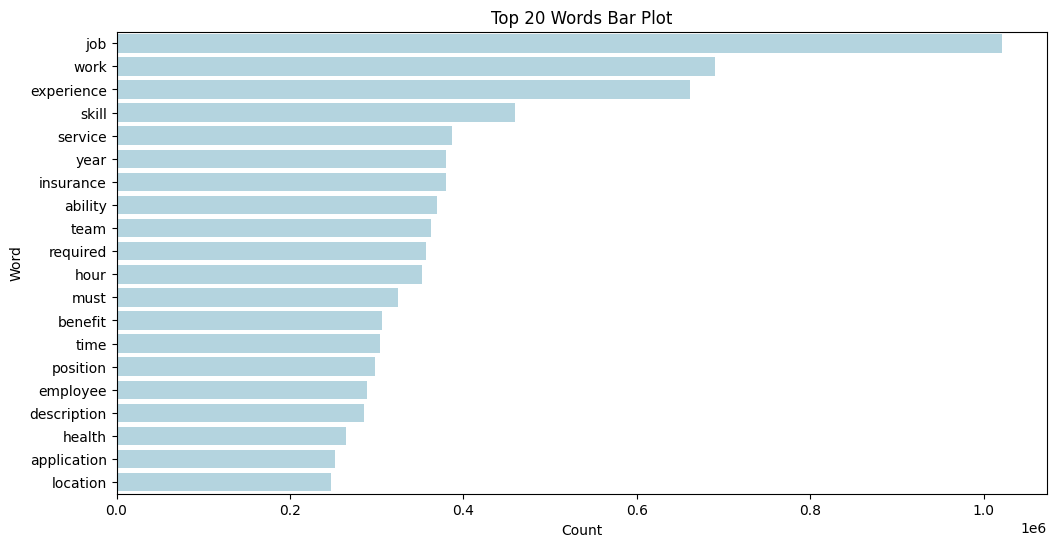

In [37]:
plot_count(df['token'], (1,1))

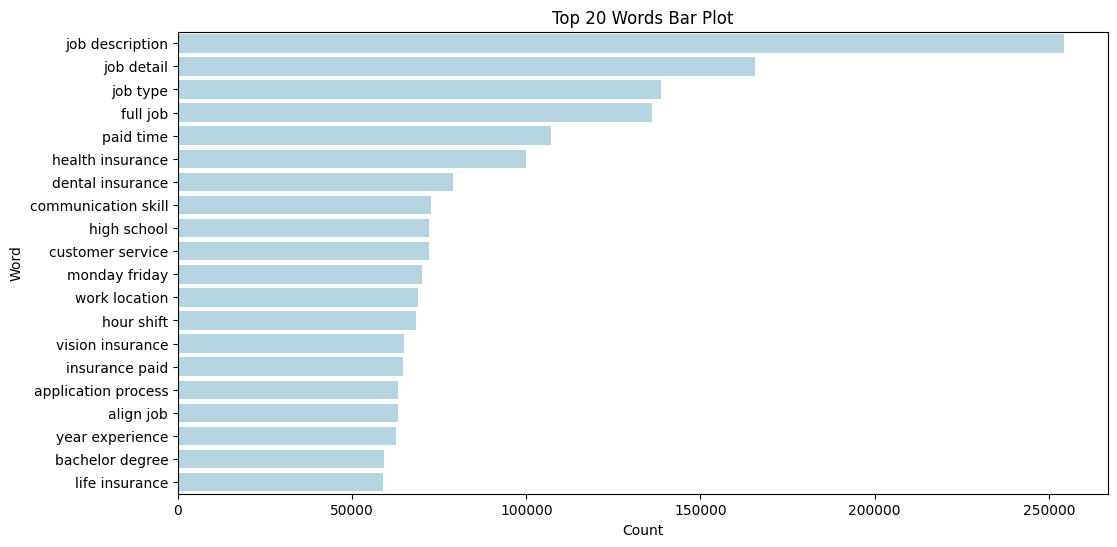

In [40]:
plot_count(df['token'], (2,2))

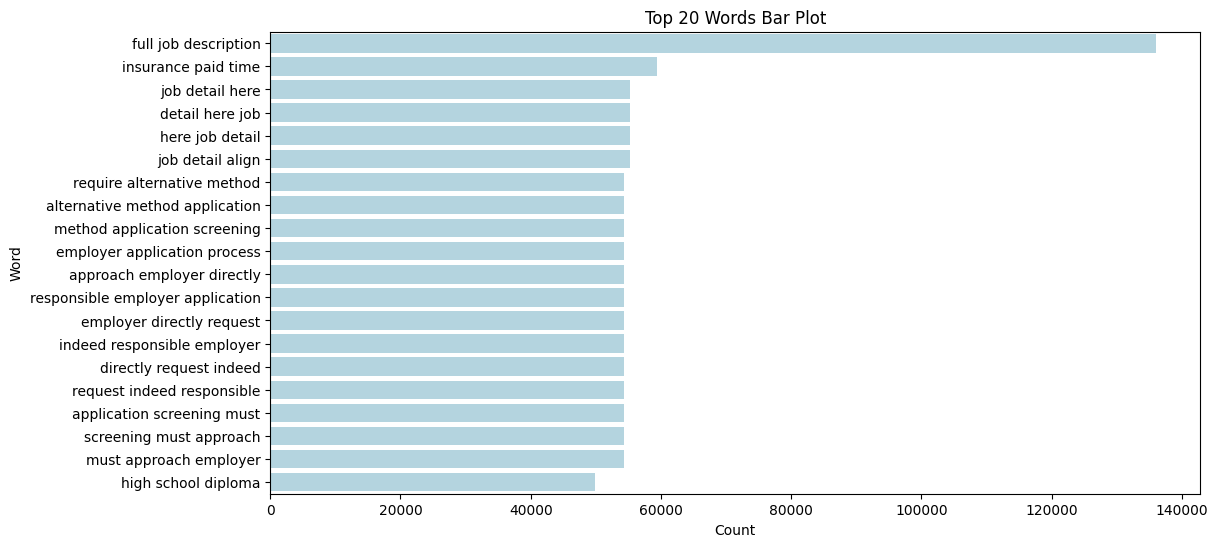

In [41]:
plot_count(df['token'], (3,3))

#### KNN to look at word clouds to see what topics there are

In [45]:
tfidf_vectorizer = TfidfVectorizer(ngram_range = (1,3), min_df = 50, max_df = 100)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['token'])

In [46]:
tfidf_matrix

<219312x150732 sparse matrix of type '<class 'numpy.float64'>'
	with 10387875 stored elements in Compressed Sparse Row format>

In [47]:
distortions = []
K = range(5, 31)
for k in tqdm(K):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    distortions.append(kmeans.inertia_)

100%|██████████| 26/26 [02:31<00:00,  5.81s/it]


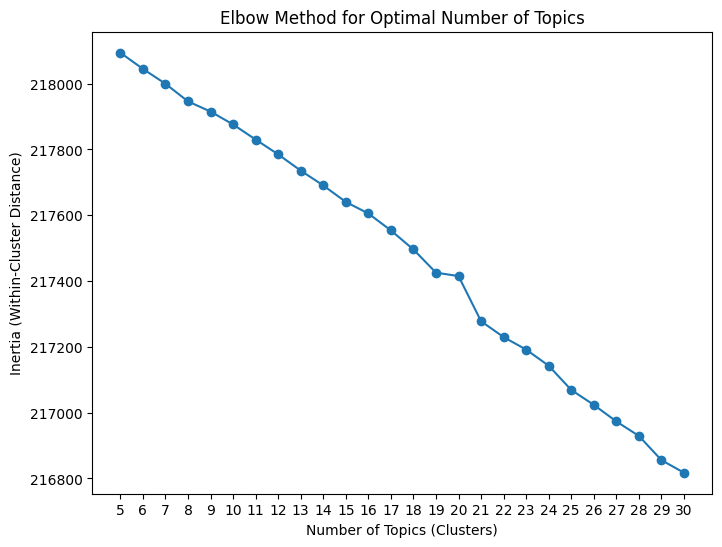

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(K, distortions, marker='o')
plt.title('Elbow Method for Optimal Number of Topics')
plt.xlabel('Number of Topics (Clusters)')
plt.ylabel('Inertia (Within-Cluster Distance)')
plt.xticks(K)
plt.show()

In [49]:
num_clusters = 21
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

In [53]:
data = pd.DataFrame({'Text': df['token'].tolist(), 'Cluster': cluster_labels})

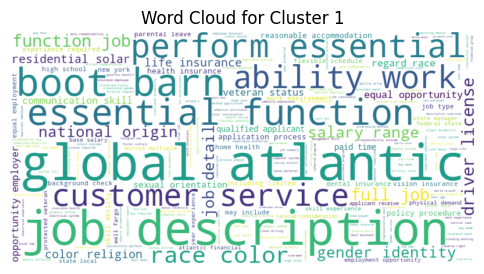

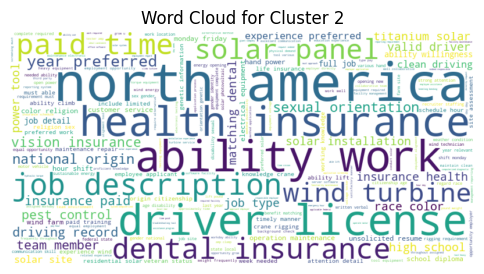

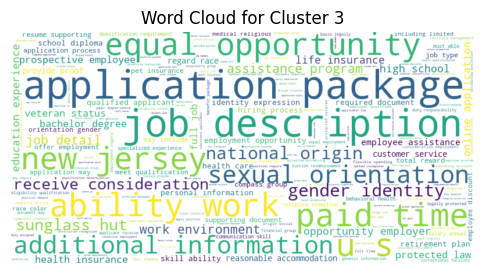

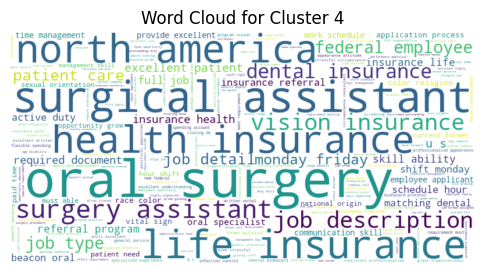

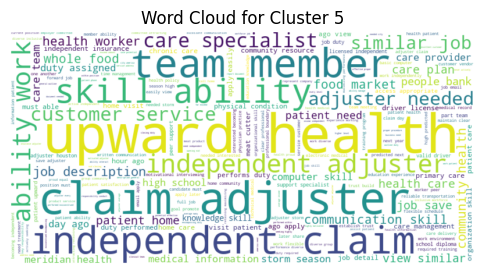

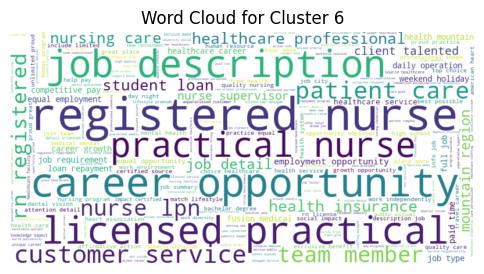

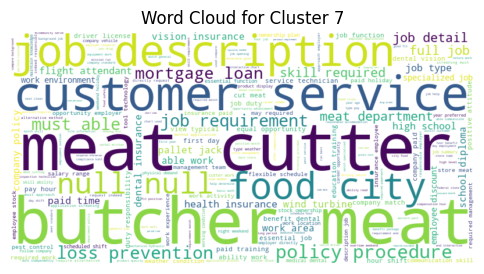

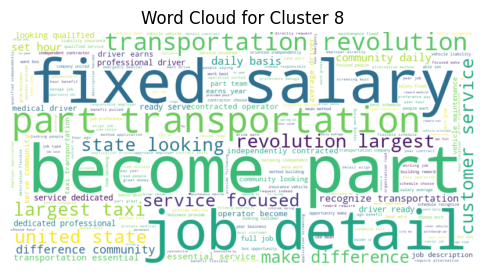

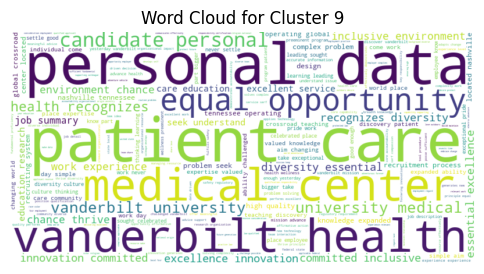

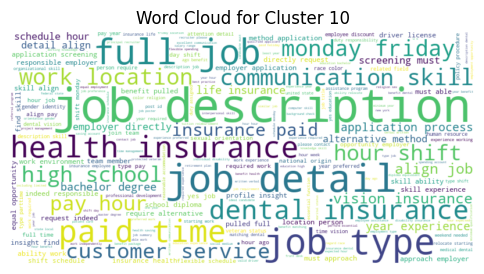

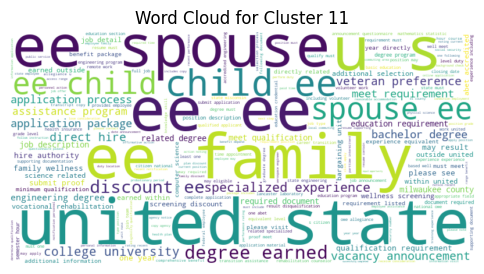

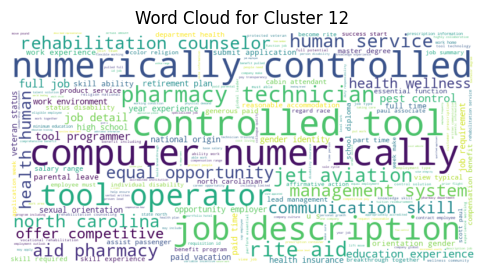

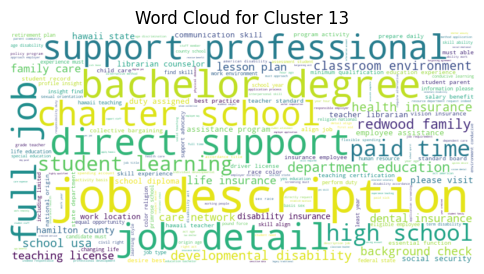

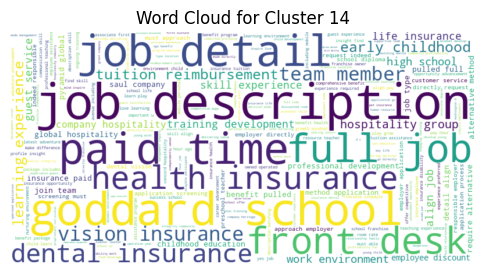

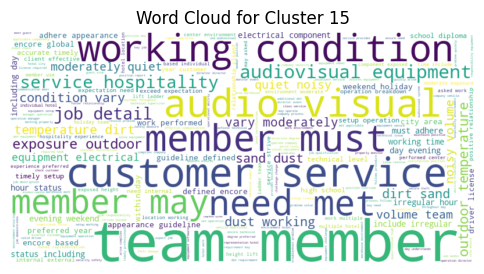

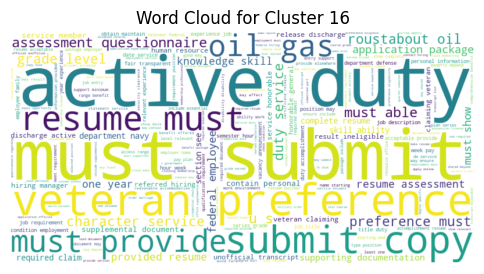

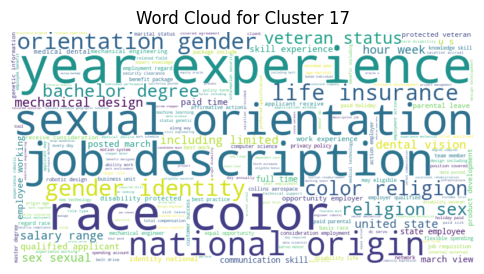

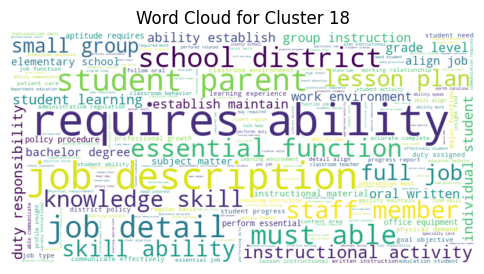

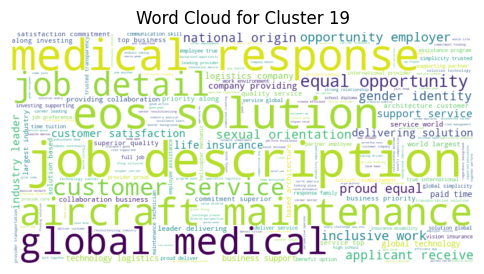

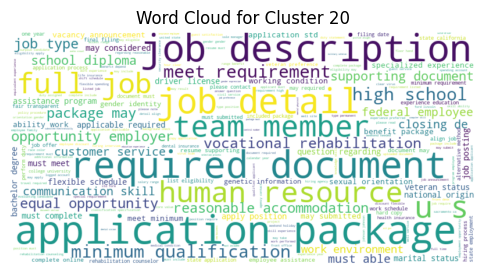

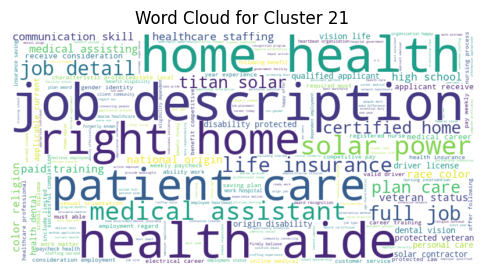

In [54]:
for cluster in range(num_clusters):
    cluster_data = data[data['Cluster'] == cluster]
    cluster_text = ' '.join(cluster_data['Text'])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_text)

    plt.figure(figsize=(6, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for Cluster {cluster + 1}")
    plt.show()